# 248 químicos sintéticos flotando en el océano

Protector solar, fármacos, pesticidas, plásticos industriales. ¿Cuántos llegan al mar? Un equipo analizó **2,315 muestras de agua** de tres océanos y encontró **248 compuestos químicos sintéticos** donde antes solo se buscaban unos pocos.

> **Paper:** *"Xenobiotics are widely distributed across marine ecosystems"*
> — Gauglitz, Schmid et al. (Nature Geoscience, 2026)
> DOI: [10.1038/s41561-026-01928-z](https://doi.org/10.1038/s41561-026-01928-z)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-21-oceano-248-quimicos-sinteticos/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/watch?v=zbwjncU6ECs)

## El problema: buscábamos lo conocido

La mayoría de estudios de contaminación marina buscan compuestos específicos — una lista predefinida de pesticidas o fármacos. Pero ¿qué pasa con los miles de químicos que *no* estamos buscando?

Usaron **espectrometría de masas no dirigida** (non-targeted tandem mass spectrometry) — una técnica que captura *todo* lo que hay en el agua, sin filtrar por compuestos conocidos. Con **21 datasets públicos** de muestras costeras y oceánicas — desde el Caribe hasta el Pacífico sur, recolectadas entre 2017 y 2022.

¿El hallazgo? **248 compuestos químicos sintéticos**, distribuidos desde arrecifes de coral hasta mar abierto.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
N_TOP = 15               # Cuántos químicos mostrar en la gráfica hero
MEDIANA_PAPER = 2.0      # Mediana reportada por el paper (%)
N_DATASETS = 21          # Datasets del meta-análisis
N_MUESTRAS = 2315        # Muestras de agua analizadas
FUENTE = 'Fuente: Gauglitz, Schmid et al. (2026), Nature Geoscience | Datos: Supplementary Materials'

COLOR_URBAN = '#DC2626'       # Rojo — químicos urbanos/industriales
COLOR_DRUG = '#2563EB'        # Azul — fármacos
COLOR_PESTICIDE = '#059669'   # Verde — pesticidas
COLOR_REF = '#D97706'         # Amber — referencia
COLORES_ECO = {'Coral Reef': '#7C3AED', 'Coastal': '#2563EB', 'Open Ocean': '#059669'}

# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

# Estilo CaM
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datos
datasets = pd.read_csv('datos/datasets.csv')
xeno_freq = pd.read_csv('datos/xenobioticos_frecuencia.csv')
contribucion = pd.read_csv('datos/contribucion_por_muestra.csv')
xeno_tipo = pd.read_csv('datos/xenobioticos_por_dataset_tipo.csv')
clases = pd.read_csv('datos/clases_quimicas.csv')

print(f"✅ {len(datasets)} datasets | {datasets['n_samples'].sum()} muestras")
print(f"✅ {len(xeno_freq)} xenobióticos con frecuencia por ecosistema")
print(f"✅ {len(contribucion)} mediciones de contribución química")
print(f"✅ {len(clases)} clases químicas principales")

✅ 20 datasets | 2299 muestras
✅ 58 xenobióticos con frecuencia por ecosistema
✅ 2321 mediciones de contribución química
✅ 15 clases químicas principales


## ¿Qué químicos aparecen en más muestras?

Aquí está.

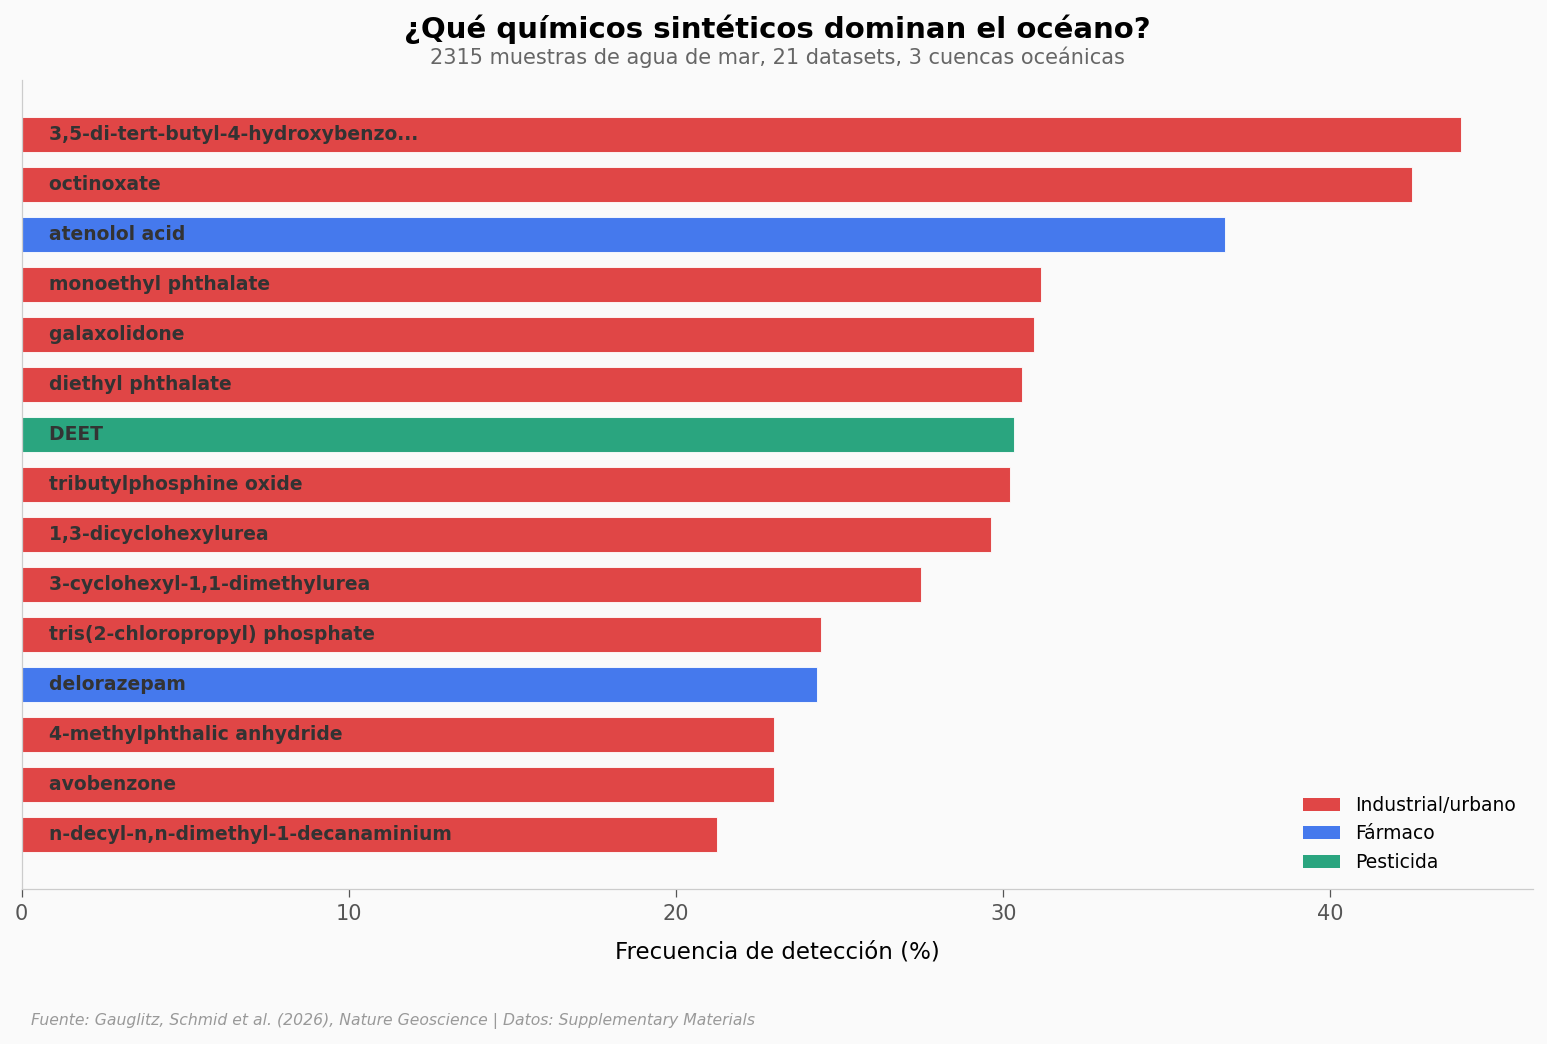

In [2]:
# Gráfica hero: Top 15 xenobióticos más frecuentes por tipo
top = xeno_freq.nlargest(N_TOP, 'freq_overall_pct').sort_values('freq_overall_pct')

fig, ax = plt.subplots(figsize=(13, 7))

color_map = {'urban': COLOR_URBAN, 'drug': COLOR_DRUG, 'pesticide': COLOR_PESTICIDE}
colors = [color_map.get(t, '#999999') for t in top['type']]

bars = ax.barh(range(len(top)), top['freq_overall_pct'], color=colors, alpha=0.85,
               edgecolor='white', linewidth=0.5, height=0.7)

# Nombres limpios a la izquierda
for i, (_, row) in enumerate(top.iterrows()):
    name = row['name']
    if len(name) > 35:
        name = name[:32] + '...'
    ax.text(top['freq_overall_pct'].max() * 0.01, i, f'  {name}',
            va='center', fontsize=9, fontweight='bold', color='#333333')

ax.set_yticks([])
ax.set_xlabel('Frecuencia de detección (%)', fontsize=11)
ax.set_title('¿Qué químicos sintéticos dominan el océano?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'{N_MUESTRAS} muestras de agua de mar, {N_DATASETS} datasets, 3 cuencas oceánicas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Leyenda por tipo
from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor=COLOR_URBAN, alpha=0.85, label='Industrial/urbano'),
    Patch(facecolor=COLOR_DRUG, alpha=0.85, label='Fármaco'),
    Patch(facecolor=COLOR_PESTICIDE, alpha=0.85, label='Pesticida'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=9, framealpha=0.9)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/top_xenobioticos.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que vemos

Los **productos industriales y urbanos** (rojo) dominan. El químico más frecuente — un antioxidante industrial (ácido 3,5-di-tert-butil-4-hidroxibenzoico) — aparece en el **44% de las muestras**. Le sigue **octinoxate**, un filtro UV presente en la mayoría de protectores solares, detectado en el 42.5%.

Los **fármacos** (azul) también aparecen: el ácido de atenolol (un metabolito de un medicamento para la hipertensión) se detecta en el 36.8% de las muestras. Y el DEET — el repelente de insectos más usado del mundo — aparece en el 30.3%.

Los **ftalatos** (plastificantes usados en envases) tienen presencias del 31% (monoetil ftalato) y 30.6% (dietil ftalato). Son compuestos que llegan al mar desde empaques, cosméticos y materiales de construcción.

## ¿Dónde se concentran? Arrecife vs costa vs mar abierto

No todos los químicos se distribuyen igual.

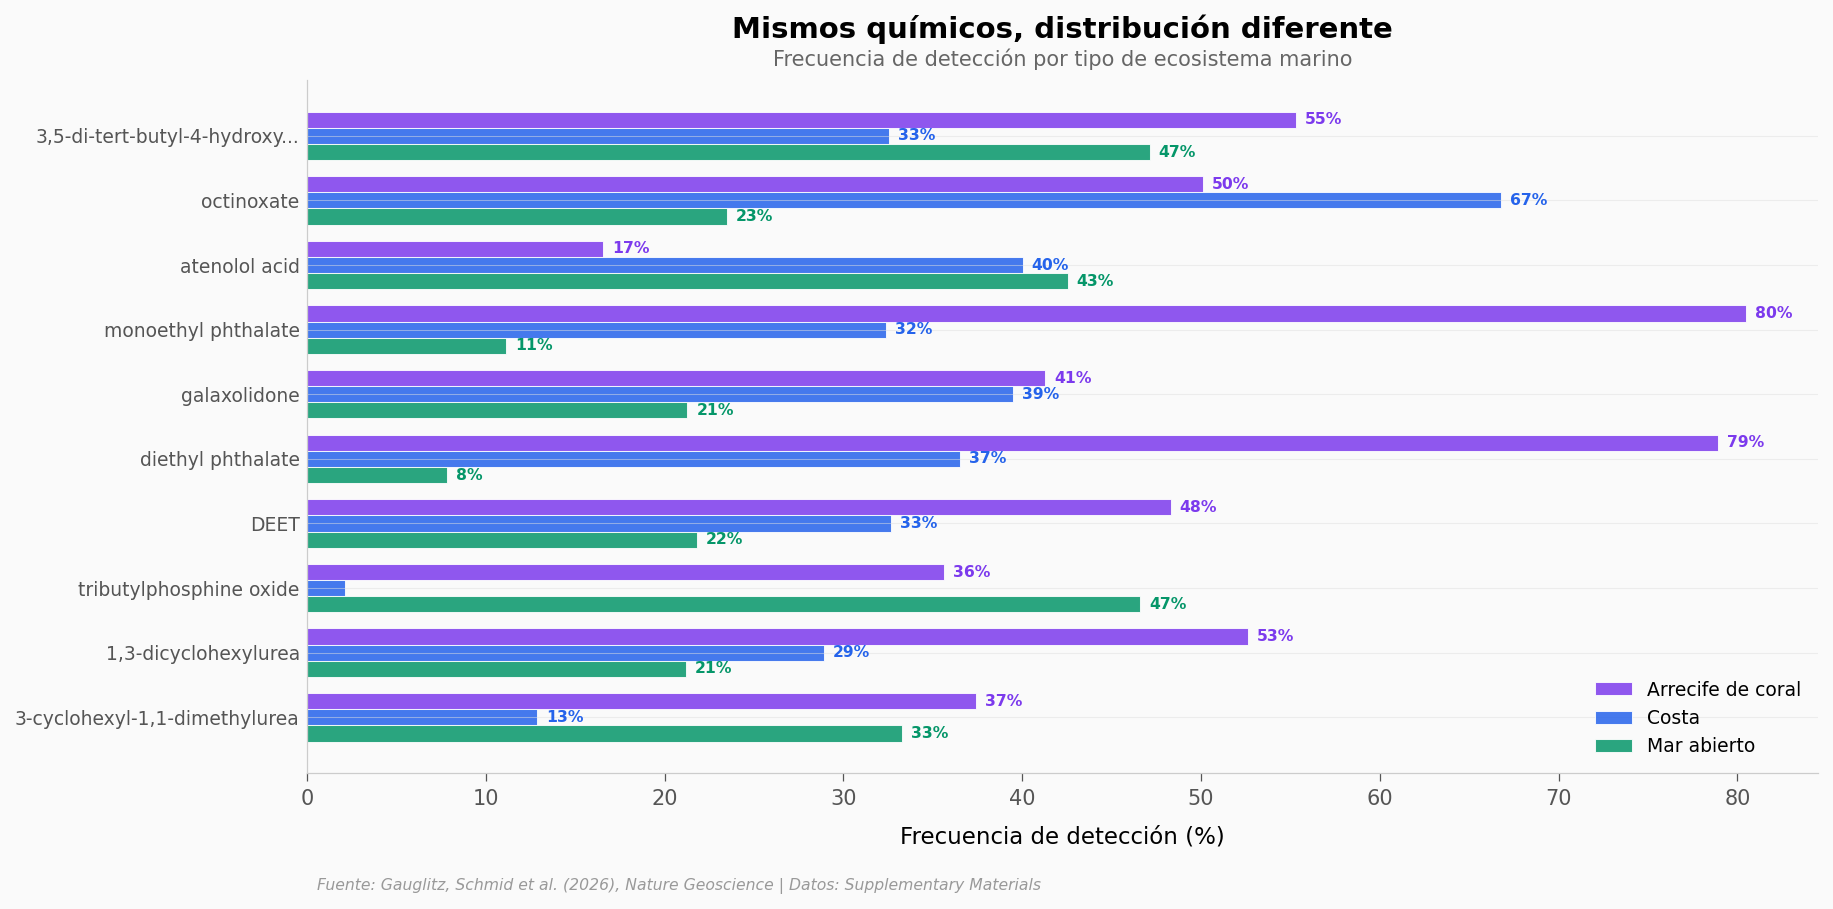

In [3]:
# Comparación: frecuencia de los top 10 químicos por ecosistema
top10 = xeno_freq.nlargest(10, 'freq_overall_pct').copy()

fig, ax = plt.subplots(figsize=(13, 6))

y_pos = np.arange(len(top10))
bar_h = 0.25

for i, (eco, col_name, color) in enumerate([
    ('Arrecife de coral', 'freq_coral_reef_pct', COLORES_ECO['Coral Reef']),
    ('Costa', 'freq_coastal_pct', COLORES_ECO['Coastal']),
    ('Mar abierto', 'freq_open_ocean_pct', COLORES_ECO['Open Ocean']),
]):
    vals = top10[col_name].values
    offset = (i - 1) * bar_h
    bars = ax.barh(y_pos + offset, vals, height=bar_h, color=color,
                   alpha=0.85, edgecolor='white', linewidth=0.5, label=eco)
    # Values at end
    for j, v in enumerate(vals):
        if v > 3:
            ax.text(v + 0.5, y_pos[j] + offset, f'{v:.0f}%',
                    va='center', fontsize=7.5, color=color, fontweight='bold')

# Names
names_clean = []
for name in top10['name'].values:
    if len(name) > 30:
        name = name[:27] + '...'
    names_clean.append(name)

ax.set_yticks(y_pos)
ax.set_yticklabels(names_clean, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Frecuencia de detección (%)', fontsize=11)
ax.set_title('Mismos químicos, distribución diferente',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Frecuencia de detección por tipo de ecosistema marino',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='lower right', framealpha=0.9)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/frecuencia_por_ecosistema.png', dpi=200, bbox_inches='tight')
plt.show()

### Los patrones cambian con la distancia a la costa

Algunos datos que saltan a la vista:
- **Monoetil ftalato** (plastificante): 80.5% en arrecifes, pero solo 11.1% en mar abierto. Un gradiente de 7:1.
- **Dietil ftalato** (otro plastificante): 78.9% en arrecifes vs 7.9% en mar abierto — gradiente 10:1.
- **Tributilfosfina** (solvente industrial): el patrón inverso — 46.6% en mar abierto y 35.6% en arrecifes, pero solo 2.1% en costa. Los compuestos industriales más persistentes muestran distribución no lineal.
- **Atenolol ácido** (fármaco): relativamente uniforme (16-42%) — se dispersa por las corrientes.

## ¿Cuánto del material orgánico disuelto es sintético?

Aquí es donde el dato se vuelve concreto. Los xenobióticos no solo *están* — contribuyen una fracción medible de la materia orgánica disuelta en el mar.

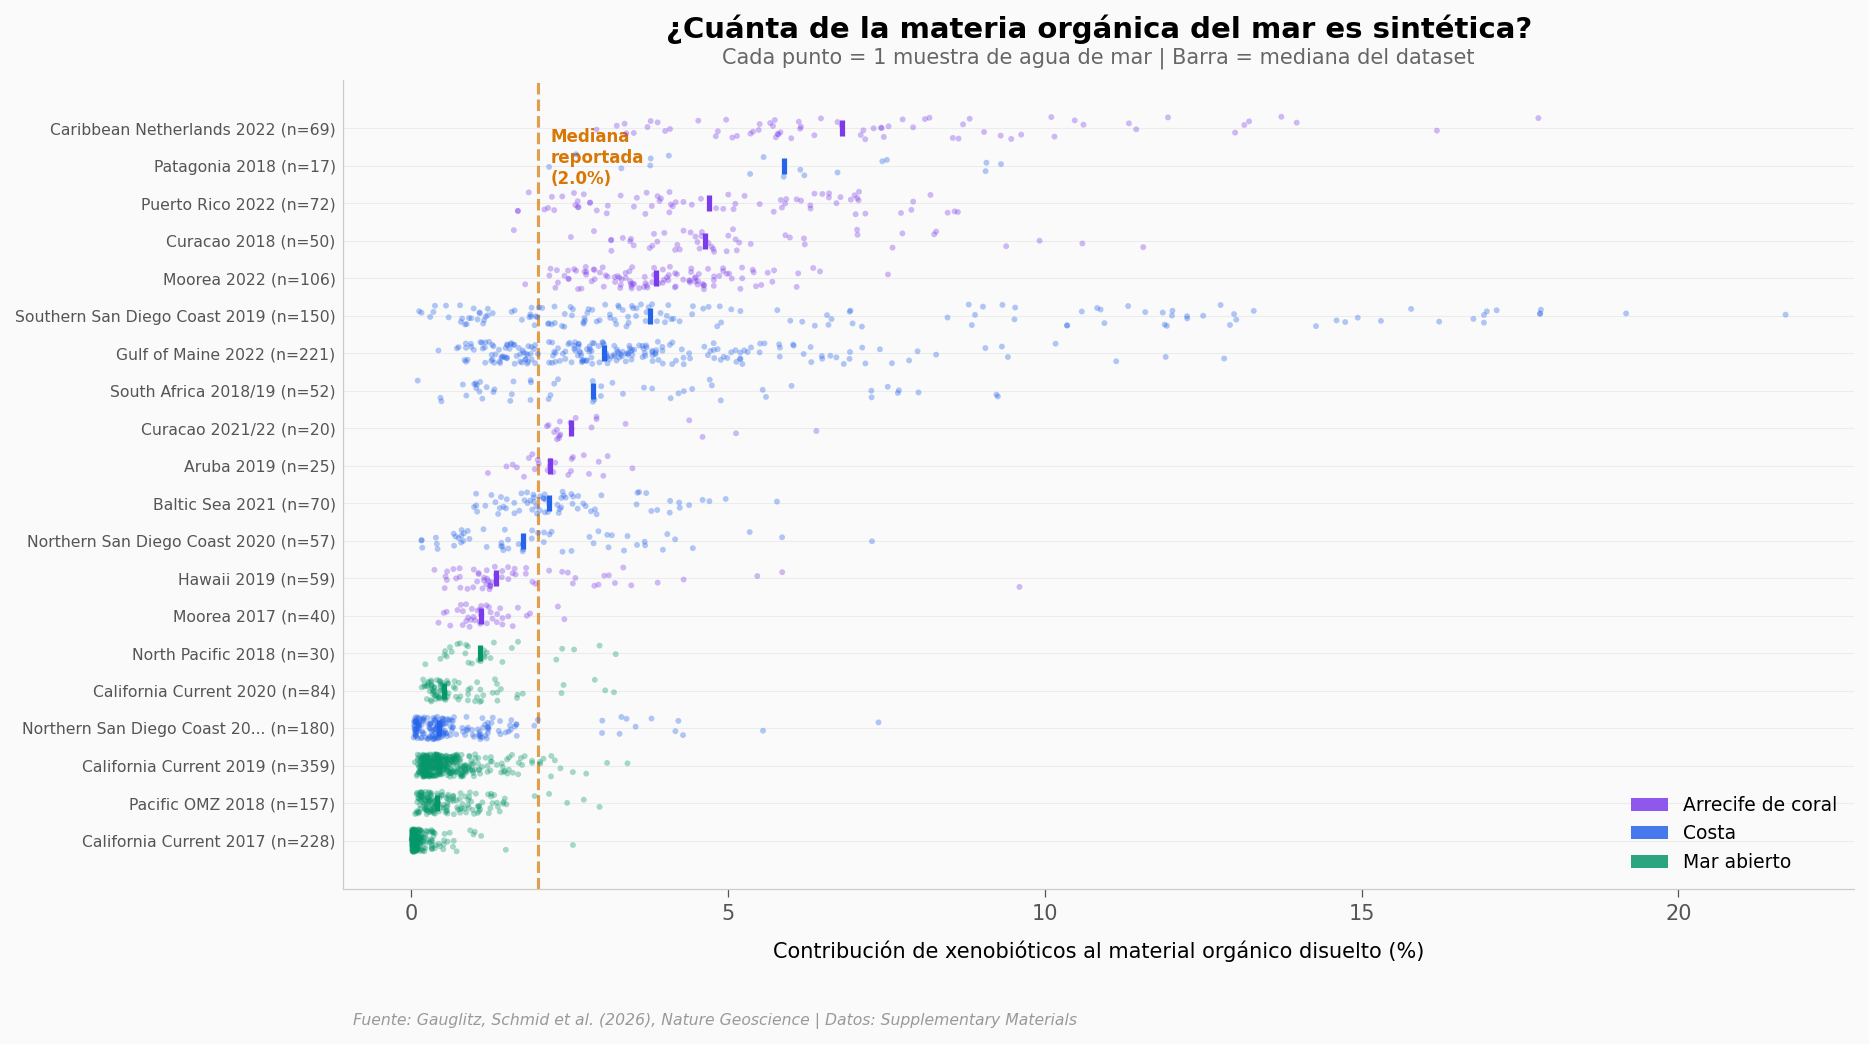

In [4]:
# Contribución xenobiótica por dataset, ordenados por mediana
medians = contribucion.groupby(['dataset', 'ecosystem'])['contribucion_xenobioticos_pct'].median()
medians = medians.reset_index().sort_values('contribucion_xenobioticos_pct')

fig, ax = plt.subplots(figsize=(13, 7))

np.random.seed(42)
for i, (_, row) in enumerate(medians.iterrows()):
    ds = row['dataset']
    eco = row['ecosystem']
    color = COLORES_ECO.get(eco, '#999999')
    sub = contribucion[contribucion['dataset'] == ds]['contribucion_xenobioticos_pct']

    # Strip plot
    n = len(sub)
    y_jitter = np.linspace(i - 0.3, i + 0.3, n)
    np.random.shuffle(y_jitter)
    ax.scatter(sub.values, y_jitter, color=color, s=8, alpha=0.35,
               edgecolors='none', zorder=4)

    # Median marker
    med = sub.median()
    ax.scatter(med, i, color=color, s=60, marker='|', linewidths=2.5, zorder=5)

# Dataset names
ds_labels = []
for _, row in medians.iterrows():
    name = row['dataset']
    if len(name) > 30:
        name = name[:27] + '...'
    ds_labels.append(f"{name} (n={contribucion[contribucion['dataset']==row['dataset']].shape[0]})")

ax.set_yticks(range(len(medians)))
ax.set_yticklabels(ds_labels, fontsize=7.5)
ax.set_xlabel('Contribución de xenobióticos al material orgánico disuelto (%)', fontsize=10)
ax.set_title('¿Cuánta de la materia orgánica del mar es sintética?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Cada punto = 1 muestra de agua de mar | Barra = mediana del dataset',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Reference lines
ax.axvline(x=MEDIANA_PAPER, color=COLOR_REF, linewidth=1.5, linestyle='--', alpha=0.7, zorder=2)
ax.text(MEDIANA_PAPER + 0.2, len(medians) - 1, f'Mediana\nreportada\n({MEDIANA_PAPER}%)',
        fontsize=8, color=COLOR_REF, fontweight='bold', va='top')

from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor=COLORES_ECO['Coral Reef'], alpha=0.85, label='Arrecife de coral'),
    Patch(facecolor=COLORES_ECO['Coastal'], alpha=0.85, label='Costa'),
    Patch(facecolor=COLORES_ECO['Open Ocean'], alpha=0.85, label='Mar abierto'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=9, framealpha=0.9)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/contribucion_por_dataset.png', dpi=200, bbox_inches='tight')
plt.show()

### Costa vs mar abierto: una diferencia de 10x

El gradiente es brutal:
- **Arrecife de coral:** mediana de 3.7% de materia orgánica es sintética (máximo 17.8%)
- **Costa:** mediana de 2.3% (máximo 21.7% — más de una de cada cinco moléculas orgánicas detectadas)
- **Mar abierto:** mediana de 0.35% (máximo 3.4%)

El gradiente arrecife → océano abierto es de **~10x** (costa → océano: ~6x). Pero incluso en mar abierto, el 0.35% no es cero — hay químicos sintéticos en muestras tomadas a cientos de kilómetros de la costa más cercana.

## ¿Qué tan raro es esto? Veamos la distribución completa.

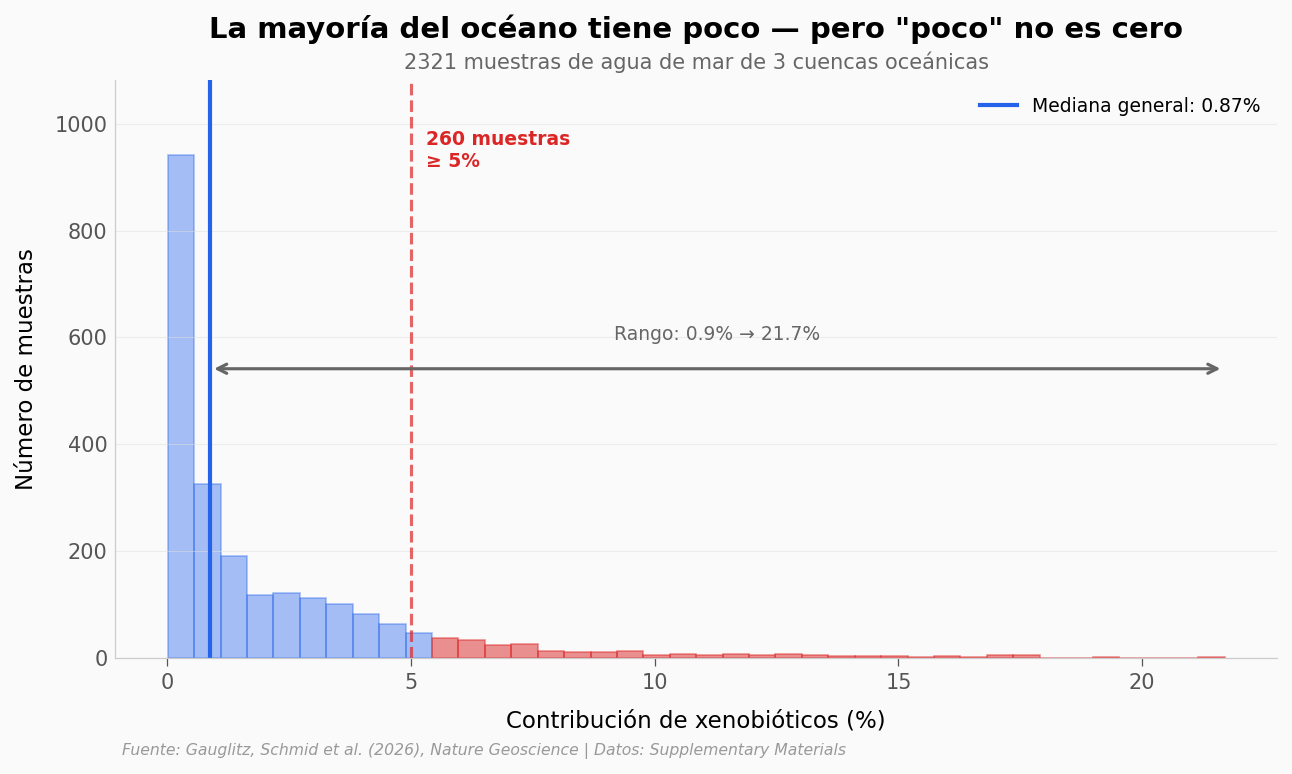

Mediana: 0.87%
Media: 2.04%
Percentil 90: 5.31%
Muestras con >5%: 260 (11.2%)
Muestras con >10%: 58 (2.5%)


In [5]:
# Histograma de contribución xenobiótica por muestra
fig, ax = plt.subplots(figsize=(10, 5))

data = contribucion['contribucion_xenobioticos_pct']
n, bins, patches = ax.hist(data, bins=40, color='#2563EB', alpha=0.4,
                           edgecolor='#2563EB', linewidth=0.8)

# Color bins > 5%
for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge >= 5:
        patch.set_facecolor('#DC2626')
        patch.set_edgecolor('#DC2626')
        patch.set_alpha(0.5)

y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

# Median lines
overall_med = data.median()
ax.axvline(x=overall_med, color='#2563EB', linewidth=2, label=f'Mediana general: {overall_med:.2f}%')
ax.axvline(x=5, color='#DC2626', linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(5.3, y_max * 0.85, f'{(data >= 5).sum()} muestras\n≥ 5%', fontsize=9,
        color='#DC2626', fontweight='bold')

# Arrow showing range
ax.annotate('', xy=(data.max(), y_max * 0.5), xytext=(overall_med, y_max * 0.5),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((overall_med + data.max()) / 2, y_max * 0.55,
        f'Rango: {overall_med:.1f}% → {data.max():.1f}%',
        fontsize=9, color='#666666', ha='center')

ax.set_xlabel('Contribución de xenobióticos (%)', fontsize=11)
ax.set_ylabel('Número de muestras', fontsize=11)
ax.set_title('La mayoría del océano tiene poco — pero "poco" no es cero',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'{len(data)} muestras de agua de mar de 3 cuencas oceánicas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(fontsize=9, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_contribucion.png', dpi=200, bbox_inches='tight')
plt.show()

# Stats
print(f"Mediana: {data.median():.2f}%")
print(f"Media: {data.mean():.2f}%")
print(f"Percentil 90: {data.quantile(0.9):.2f}%")
print(f"Muestras con >5%: {(data >= 5).sum()} ({(data >= 5).mean()*100:.1f}%)")
print(f"Muestras con >10%: {(data >= 10).sum()} ({(data >= 10).mean()*100:.1f}%)")

## Lo que los datos soportan

| Afirmación del paper | ¿Soportada? | Detalle |
|---|---|---|
| 248 xenobióticos identificados | ✅ | Confirmado: 248 compuestos en la tabla de presencia/ausencia |
| Mediana del 2% de contribución | ⚠️ | La mediana por muestra es 0.87%. El paper reporta la mediana de las *medianas por dataset* (2.17%) — una métrica que da más peso a datasets pequeños |
| Hasta 20% en zonas costeras | ✅ | Confirmado: máximo 21.7% en muestras costeras |
| 0.5% en mar abierto | ✅ | Mediana de mar abierto = 0.35%. Cercano al 0.5% reportado |
| Pesticidas y fármacos más frecuentes en costa | ⚠️ | Ftalatos (industriales, no pesticidas) sí muestran gradientes 7-10x. Pero atenolol ácido (fármaco) es más frecuente en mar abierto (42.5%) que en arrecife (16.6%) |
| Químicos industriales distribuidos ampliamente | ✅ | Tributilfosfina (solvente industrial): 46.6% en mar abierto vs 2.1% en costa |

> **Limitaciones:** (1) Los datos son de detección por espectrometría de masas — miden presencia relativa, no concentración absoluta en μg/L. (2) Las 2,315 muestras cubren 21 campañas de muestreo (2017-2022), pero no representan uniformemente todos los océanos — el Pacífico y Caribe están sobrerrepresentados. (3) La mediana del "2%" del paper depende de cómo se agregan los datos: por muestra (0.87%) o por dataset (2.17%).

> **Nota metodológica:** Esto es un meta-análisis — observación, no experimento. Los datos muestran que *a más lejos de la costa, menos químicos*, pero no prueban que la distancia sea la causa. Corrientes, profundidad y cercanía a fuentes puntuales podrían explicar los patrones.

## Ahora tú

1. **¿Qué clase química domina?** Usa el CSV de clases (`clases_quimicas.csv`) para ver las 15 familias más comunes. ¿Los glicoles (polietilenglicol, polímeros industriales) dominan sobre los ftalatos?

2. **¿Cuántos químicos comparten arrecife y mar abierto?** Filtra `xenobioticos_frecuencia.csv` para compuestos detectados >10% en AMBOS ecosistemas. ¿Son los mismos tipos?

3. **Prueba cambiar `N_TOP`** a 30 en la celda de configuración. ¿Los pesticidas ganan presencia en el fondo de la lista?

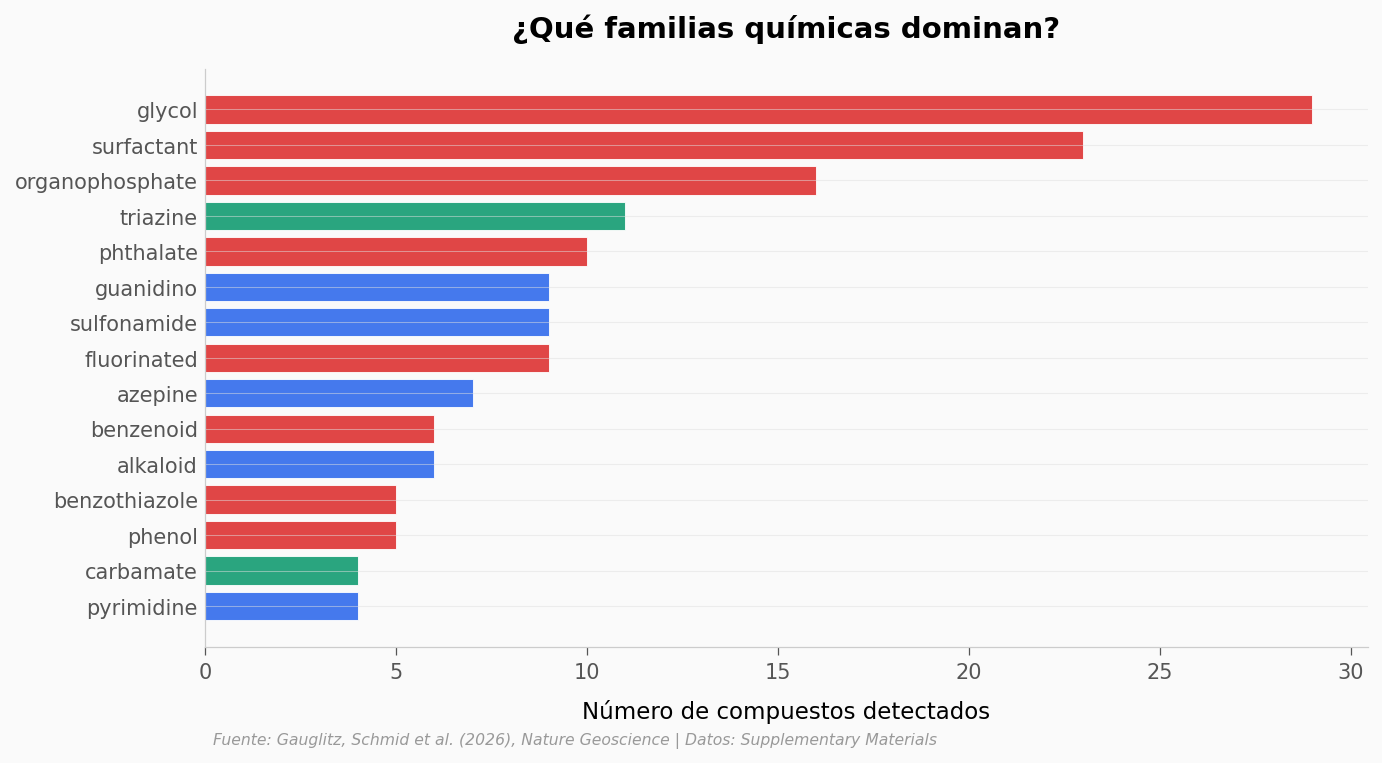

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Qué clases químicas dominan entre los 248 xenobióticos?
fig, ax = plt.subplots(figsize=(10, 5))

colors_cls = [COLOR_URBAN if c in ['glycol', 'surfactant', 'organophosphate', 'phthalate',
                                     'fluorinated', 'benzothiazole', 'phenol', 'benzenoid']
              else COLOR_DRUG if c in ['sulfonamide', 'guanidino', 'azepine', 'alkaloid',
                                        'pyrimidine']
              else COLOR_PESTICIDE
              for c in clases['Class']]

ax.barh(clases['Class'][::-1], clases['count'][::-1],
        color=colors_cls[::-1], alpha=0.85, edgecolor='white')
ax.set_xlabel('Número de compuestos detectados', fontsize=11)
ax.set_title('¿Qué familias químicas dominan?',
             fontsize=14, fontweight='bold', pad=15)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/clases_quimicas.png', dpi=200, bbox_inches='tight')
plt.show()

---

## Créditos

- **Paper:** Gauglitz, Schmid et al. (2026). *"Xenobiotics are widely distributed across marine ecosystems."* Nature Geoscience. DOI: [10.1038/s41561-026-01928-z](https://doi.org/10.1038/s41561-026-01928-z)
- **Datos:** Supplementary Materials del paper (CSVs y XLSX). Datos originales en [MassIVE repository](https://massive.ucsd.edu)
- **Código:** [GitHub — Ciencia a Mordiscos / El Lab](https://github.com/Ciencia-a-Mordiscos/lab)
- **Licencia:** CC-BY-4.0